In [4]:
import os
import random
import torch
import platform
import numpy as np

In [6]:
## For Reproducibility

In [8]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [10]:
## Hardware specifications

In [12]:
if torch.cuda.is_available():
    !nvidia-smi
elif torch.backends.mps.is_available():
    print("✅ MPS (Apple Silicon GPU) is available.")
    print("macOS Version:", platform.mac_ver()[0])
    print("Torch MPS support:", torch.backends.mps.is_available())
else:
    print("⚠️ No GPU detected. Using CPU.")

✅ MPS (Apple Silicon GPU) is available.
macOS Version: 15.3.2
Torch MPS support: True


In [14]:
## Device GPU Usage

In [16]:
if torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple M1/M2/M3/M4 GPU
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
device_type = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

Using device: mps


In [18]:
## Transforming Functions

In [20]:
from torchvision import transforms

input_size = 224

train_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.CenterCrop(input_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [21]:
## Importing Dataset

In [22]:
import shutil
from torchvision import datasets
from PIL import Image
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit

# Define dataset path
dataset_path = '../../../datasets/helmet_dataset'

# Clean .ipynb_checkpoints if present
checkpoints_path = os.path.join(dataset_path, ".ipynb_checkpoints")
if os.path.exists(checkpoints_path):
    shutil.rmtree(checkpoints_path)
    print("Removed .ipynb_checkpoints folder.")

# Custom image loader
def pil_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

def is_valid_image(path):
    return not any(x in path for x in ['.DS_Store', '.ipynb_checkpoints'])

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None,
    loader=pil_loader,
    is_valid_file=is_valid_image
)

print("Classes:", dataset.classes)
print("Class-to-index:", dataset.class_to_idx)


Classes: ['looking', 'not_looking']
Class-to-index: {'looking': 0, 'not_looking': 1}


In [23]:
from collections import Counter

# Total number of images
print("Total images:", len(dataset))

# Per-class image count
class_counts = Counter(dataset.targets)
for idx, class_name in enumerate(dataset.classes):
    print(f"Class '{class_name}': {class_counts[idx]} images")


Total images: 1799
Class 'looking': 899 images
Class 'not_looking': 900 images


In [24]:
## Datasplit & Applying Transform Functions

In [25]:
from collections import Counter
import numpy as np

targets = dataset.targets
class_names = dataset.classes

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, val_idx = next(splitter.split(np.zeros(len(targets)), targets))

# Print counts
print(f"\nTotal dataset size: {len(dataset)}")
print(f"Training set size: {len(train_idx)} ({(len(train_idx) / len(dataset)) * 100:.1f}%)")
print(f"Validation set size: {len(val_idx)} ({(len(val_idx) / len(dataset)) * 100:.1f}%)")

# Count class distribution in splits
train_targets = [targets[i] for i in train_idx]
val_targets = [targets[i] for i in val_idx]

train_class_counts = Counter(train_targets)
val_class_counts = Counter(val_targets)

print("\n📊 Training class distribution:")
for cls_idx, count in train_class_counts.items():
    print(f"  {class_names[cls_idx]}: {count} images")

print("\n📊 Validation class distribution:")
for cls_idx, count in val_class_counts.items():
    print(f"  {class_names[cls_idx]}: {count} images")

# Apply transform after split
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return self.transform(image), label
    def __len__(self):
        return len(self.subset)

train_dataset = TransformedSubset(Subset(dataset, train_idx), train_transform)
val_dataset = TransformedSubset(Subset(dataset, val_idx), val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)



Total dataset size: 1799
Training set size: 1259 (70.0%)
Validation set size: 540 (30.0%)

📊 Training class distribution:
  not_looking: 630 images
  looking: 629 images

📊 Validation class distribution:
  looking: 270 images
  not_looking: 270 images


In [26]:
## Preview of Transformed Models

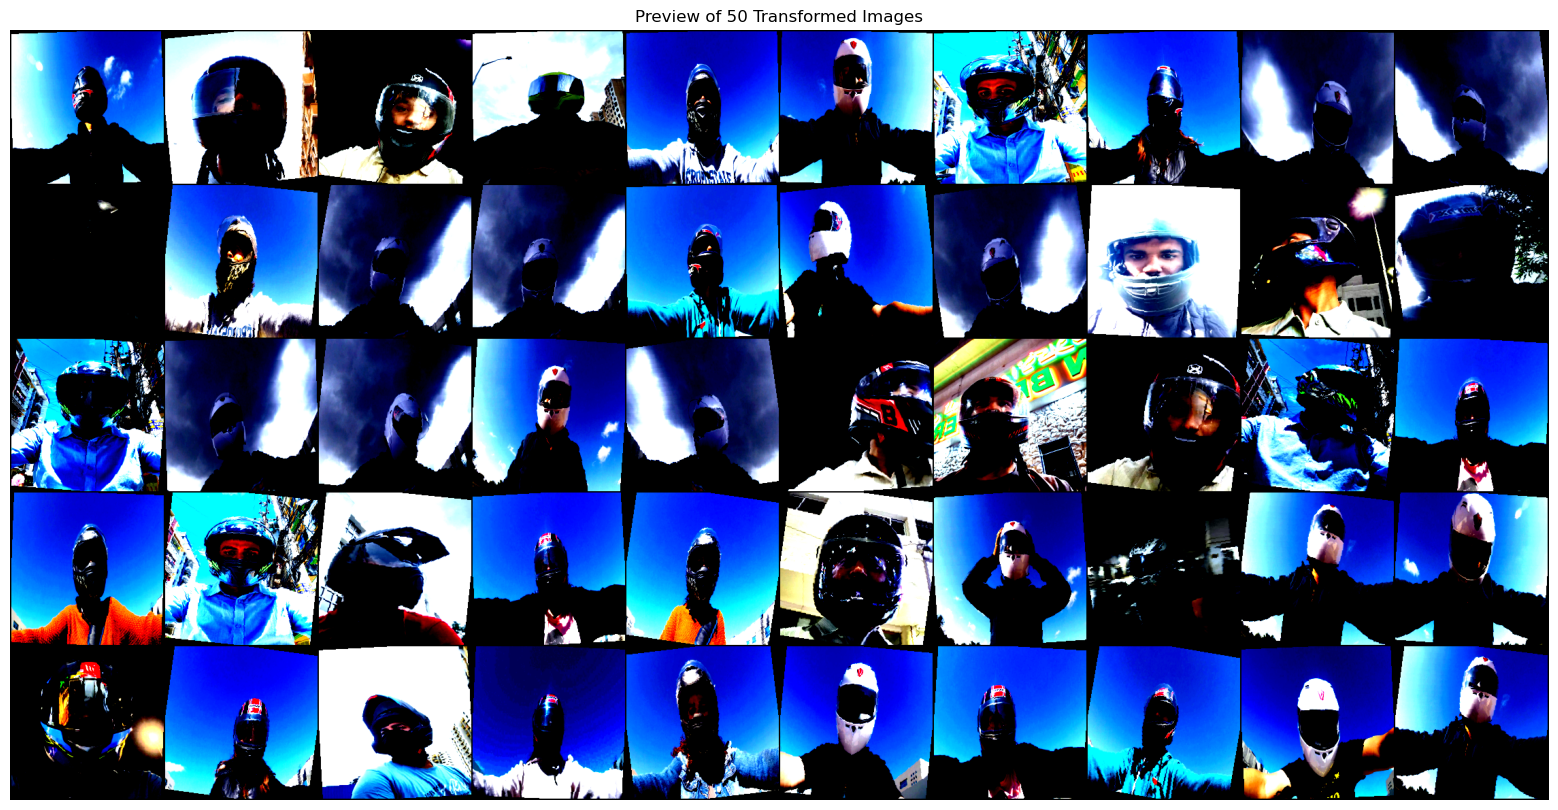

In [27]:
import torchvision
import matplotlib.pyplot as plt

preview_dataset = datasets.ImageFolder(dataset_path, transform=train_transform, loader=pil_loader)
preview_loader = DataLoader(preview_dataset, batch_size=50, shuffle=True)

images, _ = next(iter(preview_loader))
grid_img = torchvision.utils.make_grid(images[:50], nrow=10, padding=2)
np_img = grid_img.permute(1, 2, 0).numpy()

plt.figure(figsize=(20, 10))
plt.imshow(np.clip(np_img, 0, 1))
plt.axis('off')
plt.title("Preview of 50 Transformed Images")
plt.show()


In [35]:
## Model Training and Fine Tuning

In [36]:
import torch
import timm
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from itertools import product

# # Load model
# model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=2)
# model.to(device)

In [40]:
# --- Define your parameter grid ---
from itertools import product

param_grid = {
    # "lr": [1e-3, 1e-4],                 # reduced to 2
    # "batch_size": [32],                 # fixed to 1
    # "weight_decay": [0, 1e-4],          # reduced to 2
    "lr": [1e-3],               
    "batch_size": [32],                
    "weight_decay": [1e-4],         
    "optimizer": ["AdamW"]       # keep both for comparison
}

all_configs = list(product(*param_grid.values()))
param_keys = list(param_grid.keys())


In [42]:
# --- Model freezing utility ---
# def freeze_backbone(model, freeze_until=None):
#     if freeze_until is None:
#         return
#     for name, param in model.named_parameters():
#         if freeze_until not in name:
#             param.requires_grad = False

In [44]:
# Early stopping
best_val_acc = 0
best_epoch = 0
epochs_no_improve = 0
patience = 3
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_preds, best_labels = [], []
best_model_state = None

In [46]:
global_best_acc = 0
global_best_config = None
global_best_model = None

for config in all_configs:
    params = dict(zip(param_keys, config))
    print(f"\n🔧 Running config: {params}")

    # Load model and optionally freeze layers
    model_name = "efficientnet_b0"   # change this for each model run
    model = timm.create_model(model_name, pretrained=True, num_classes=2).to(device)

    # freeze_backbone(model, freeze_until="blocks.4")

    # Optimizer
    optimizer = optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    
    # Criterion
    criterion = nn.CrossEntropyLoss()
    
    # Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    # Dataloaders
    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=params["batch_size"])

    # Reset tracking metrics for this run
    best_val_acc = 0
    best_epoch = 0
    epochs_no_improve = 0
    patience = 3
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_preds, best_labels = [], []
    best_model_state = None

    # ✅ BEGIN TRAINING FOR THIS CONFIG
    for epoch in range(15):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()                 
            optimizer.step()                    

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            total_loss += loss.item()

        scheduler.step()

        train_losses.append(total_loss)
        train_accuracies.append(100 * correct / total)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        val_preds, val_targets = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = outputs.max(1)
                val_loss += loss.item()
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)
                val_preds.extend(preds.cpu().tolist())
                val_targets.extend(labels.cpu().tolist())

        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1} | Train Acc: {train_accuracies[-1]:.2f}% | Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_preds = val_preds
            best_labels = val_targets
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("⏹️ Early stopping triggered.")
                break

    # Reload best model state for this config
    model.load_state_dict(best_model_state)
    if best_val_acc > global_best_acc:
        global_best_acc = best_val_acc
        global_best_config = params
        global_best_model = best_model_state

    print(f"✅ Best Val Acc for config {params}: {best_val_acc:.2f}% at epoch {best_epoch}")



🔧 Running config: {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'optimizer': 'AdamW'}
Epoch 1 | Train Acc: 79.67% | Val Acc: 89.07%
Epoch 2 | Train Acc: 90.15% | Val Acc: 89.81%
Epoch 3 | Train Acc: 91.82% | Val Acc: 93.33%
Epoch 4 | Train Acc: 94.36% | Val Acc: 94.63%
Epoch 5 | Train Acc: 97.06% | Val Acc: 93.52%
Epoch 6 | Train Acc: 97.62% | Val Acc: 93.70%
Epoch 7 | Train Acc: 98.81% | Val Acc: 95.00%
Epoch 8 | Train Acc: 99.05% | Val Acc: 95.56%
Epoch 9 | Train Acc: 99.60% | Val Acc: 95.19%
Epoch 10 | Train Acc: 99.05% | Val Acc: 95.37%
Epoch 11 | Train Acc: 99.05% | Val Acc: 95.56%
⏹️ Early stopping triggered.
✅ Best Val Acc for config {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'optimizer': 'AdamW'}: 95.56% at epoch 8


In [47]:
print("\n Best Configuration Overall:")
print(f"Params: {global_best_config}")
print(f"Validation Accuracy: {global_best_acc:.2f}%")


 Best Configuration Overall:
Params: {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'optimizer': 'AdamW'}
Validation Accuracy: 95.56%


In [48]:
print(f"\nBest Epoch: {best_epoch} | Val Accuracy: {best_val_acc:.2f}%")
print("\nClassification Report (Best Epoch):")
print(classification_report(best_labels, best_preds, target_names=dataset.classes))


Best Epoch: 8 | Val Accuracy: 95.56%

Classification Report (Best Epoch):
              precision    recall  f1-score   support

     looking       0.97      0.94      0.96       270
 not_looking       0.95      0.97      0.96       270

    accuracy                           0.96       540
   macro avg       0.96      0.96      0.96       540
weighted avg       0.96      0.96      0.96       540



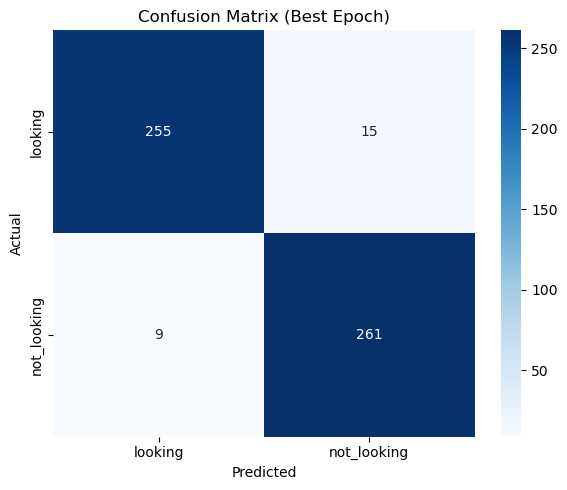

In [49]:
cm = confusion_matrix(best_labels, best_preds)
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)
plt.title("Confusion Matrix (Best Epoch)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [50]:
epochs_range = range(1, len(train_accuracies) + 1)

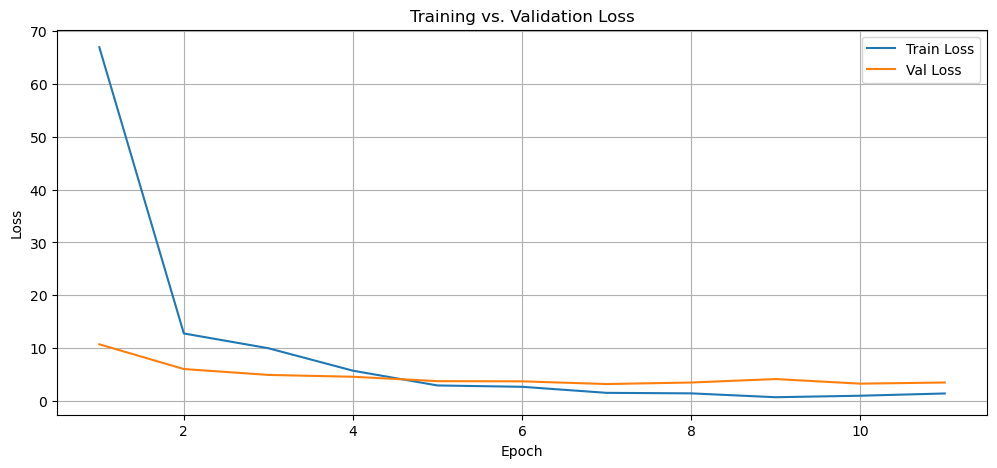

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

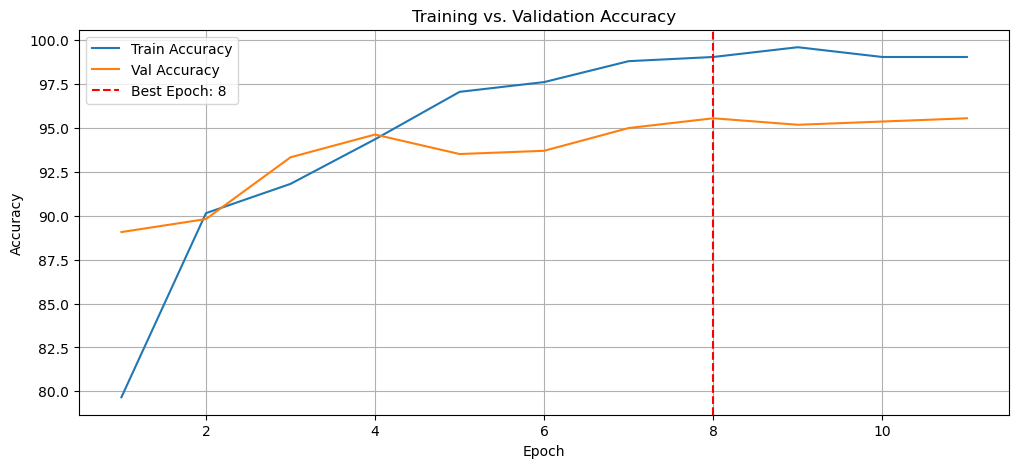

In [52]:
plt.figure(figsize=(12, 5))
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

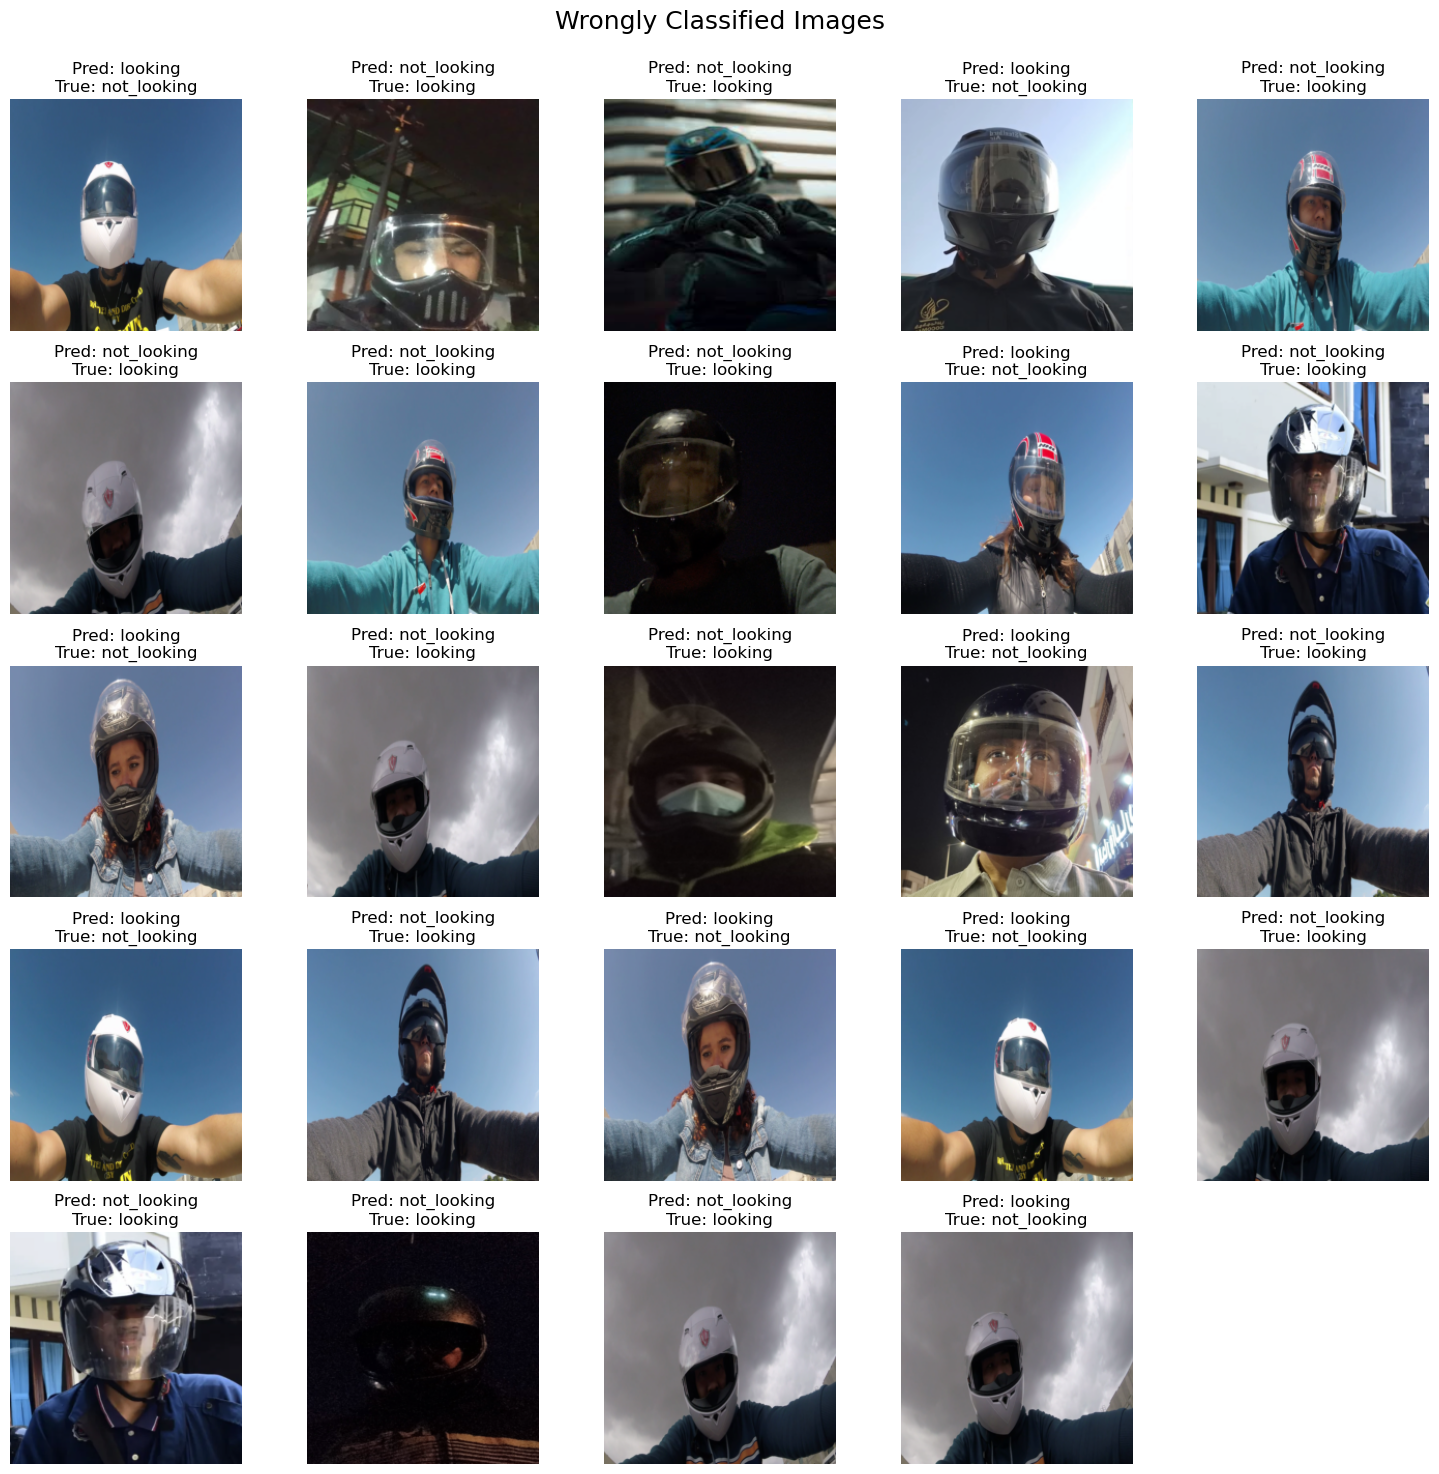

In [53]:
misclassified = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for img, pred, true in zip(images, preds, labels):
            if pred != true:
                misclassified.append((img.cpu(), pred.item(), true.item()))

plt.figure(figsize=(15, 15))
for idx, (img, pred, true) in enumerate(misclassified[:25]):
    img = img.permute(1, 2, 0).numpy()
    img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    img = np.clip(img, 0, 1)
    plt.subplot(5, 5, idx + 1)
    plt.imshow(img)
    plt.title(f"Pred: {dataset.classes[pred]}\nTrue: {dataset.classes[true]}")
    plt.axis('off')
plt.tight_layout()
plt.suptitle("Wrongly Classified Images", fontsize=18)
plt.subplots_adjust(top=0.92)
plt.show()

In [ ]:
torch.save(global_best_model, "efficientnet_b0.pth")
print("Best model saved as 'efficientnet_b0.pth'")